## Import Packages

Resolution is 64 x 64

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from torch.optim import Adam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torchmetrics.classification import BinaryPrecision, BinaryRecall, BinaryAUROC, BinaryAveragePrecision, BinaryF1Score
from sklearn.preprocessing import StandardScaler                                               
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve      
from torch.utils.data import DataLoader, TensorDataset

In [2]:
!nvidia-smi

Tue May 27 20:03:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.51.03              Driver Version: 575.51.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:01:00.0 Off |                    0 |
| N/A   32C    P0             51W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Import Datasets

In [3]:
base_path = '/gws/nopw/j04/wiser_ewsa/mrakotomanga/EPS/Data/Zambia/64x64/full'

In [4]:
lead_time = 1

In [5]:
test_data_X = pd.read_csv(f'{base_path}/test/test-data-zambia-input-t0.csv')
test_data_y_t0 = pd.read_csv(f'{base_path}/test/test-data-zambia-output-map-t0.csv', header=None)
test_data_y_t = pd.read_csv(f'{base_path}/test/test-data-zambia-output-map-t{lead_time}.csv', header=None)

In [6]:
train_data_X = pd.read_csv(f'{base_path}/train/train-data-zambia-input-t0.csv')
train_data_y_t = pd.read_csv(f'{base_path}/train/train-data-zambia-output-map-t{lead_time}.csv', header=None)

In [7]:
resolution_y, resolution_x = 64, 64

test_data_y_t = test_data_y_t.to_numpy().reshape(len(test_data_y_t), resolution_y, resolution_x)
train_data_y_t = train_data_y_t.to_numpy().reshape(len(train_data_y_t), resolution_y, resolution_x)

In [8]:
fract_storm_test = np.sum(test_data_y_t) / len(test_data_y_t.flatten())
fract_storm_train = np.sum(train_data_y_t) / len(train_data_y_t.flatten())

print(fract_storm_test)
print(fract_storm_train)

0.01172119717300209
0.011892655154578366


### Preprocessing

Log transforming

In [9]:
train_data_X

,year,month,day,hour,minute,lat1,lat2,lon1,lon2,wp1,wp2,size1,size2,d1,d2,mask1,mask2
0,2004,1,19,10,30,-13.016368,-13.957932,27.164442,27.875416,183.444444,130.923077,243,117,90.543730,107.365682,1,1
1,2004,1,19,10,45,-12.988157,-13.887567,27.193869,28.612118,177.222222,108.250000,243,324,87.352261,118.838390,1,1
2,2004,1,19,11,0,-13.045341,-14.256007,27.168625,28.194260,153.384615,210.613636,234,2376,90.208105,141.230377,1,1
3,2004,1,19,11,15,-12.915976,-13.102478,27.887129,27.143270,185.000000,147.064516,180,279,15.391401,93.500041,1,1
4,2004,1,19,11,30,-12.915297,-13.166731,27.853437,27.453335,193.387097,108.375000,279,144,18.464673,62.043267,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126088,2019,12,31,22,45,-15.324207,-14.780192,23.885836,32.732544,163.000000,154.023810,126,378,513.331003,547.827142,1,1
126089,2019,12,31,23,0,-15.352759,-14.747602,23.857620,32.616074,195.063492,153.333333,567,594,517.533871,534.830563,1,1
126090,2019,12,31,23,15,-14.568342,-15.351405,32.507008,23.792900,162.052632,214.232394,855,1278,516.998602,523.491359,1,1
126091,2019,12,31,23,30,-14.564439,-15.174613,32.360569,23.703260,152.371429,219.153439,945,1701,501.993815,522.665848,1,1


In [10]:
train_data_X, val_data_X, train_y_lt, val_y_lt = train_test_split(train_data_X, train_data_y_t, test_size=0.3, random_state=12)

In [11]:
for col in ['size1', 'size2', 'wp1', 'wp2', 'd1', 'd2']:
    train_data_X[col] = np.log1p(train_data_X[col].astype(float)).astype(float)
    test_data_X[col] = np.log1p(test_data_X[col].astype(float)).astype(float)
    val_data_X[col] = np.log1p(val_data_X[col].astype(float)).astype(float)

### Scaling

In [12]:
# Exclude mask columns from scaling
mask_cols = ['mask1', 'mask2']

# Final list of features to scale
cols_to_scale = [col for col in train_data_X.columns 
                 if col not in mask_cols]

scaler = StandardScaler()

X_train_scaled = train_data_X.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(train_data_X[cols_to_scale])

X_val_scaled = val_data_X.copy()
X_val_scaled[cols_to_scale] = scaler.transform(val_data_X[cols_to_scale])

X_test_scaled = test_data_X.copy()
X_test_scaled[cols_to_scale] = scaler.transform(test_data_X[cols_to_scale])

dump(scaler, "/content/drive/MyDrive/Zambia/t0-only/Zambia-scaler-lt1-t0-only.bin", compress=True)

In [ ]:
x_train = X_train_scaled.to_numpy()
y_train = train_y_lt

x_val = X_val_scaled.to_numpy()
y_val = val_y_lt

x_test = X_test_scaled.to_numpy()
y_test = test_data_y_t

In [14]:
class UpsampleCNN(nn.Module):
    
    def __init__(self, input_dim=17, initial_size=8, output_size=(64, 64)):
        super(UpsampleCNN, self).__init__()
        self.initial_size = initial_size
        self.output_size = output_size  # Store target upsampled size

        self.fc1 = nn.Linear(input_dim, 256)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(256, initial_size * initial_size * 16)

        self.conv1 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.final_conv = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))

        # Reshape to image-like tensor
        x = x.view(-1, 16, self.initial_size, self.initial_size)

        # Upsample directly to target size (e.g., 64x64)
        x = F.interpolate(x, size=self.output_size, mode='nearest')

        # Convolutional refinement
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))

        # Final prediction map
        x = torch.sigmoid(self.final_conv(x))  # Shape: (B, 1, 64, 64)
        return x


# Create model instance
model = UpsampleCNN()
print(model)


UpsampleCNN(
  (fc1): Linear(in_features=17, out_features=256, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=256, out_features=1024, bias=True)
  (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (final_conv): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1))
)


In [ ]:
class LightningUpsampleModel(pl.LightningModule):
    def __init__(self, input_dim=17, lr=1e-3, threshold=0.15):
        super().__init__()
        self.model = UpsampleCNN(input_dim=input_dim)  # use the model from earlier

        self.criterion = nn.BCELoss()

        # Metrics
        self.precision = BinaryPrecision(threshold=threshold)
        self.recall = BinaryRecall(threshold=threshold)
        self.f1 = BinaryF1Score(threshold=threshold)
        self.auc = BinaryAUROC()
        self.prc = BinaryAveragePrecision()
        self.lr = lr

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze(1)
        loss = self.criterion(y_hat, y)

        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze(1)

        self.precision.update(y_hat, y)
        self.recall.update(y_hat, y)
        self.f1.update(y_hat, y)
        self.auc.update(y_hat, y)
        self.prc.update(y_hat, y)

        loss = self.criterion(y_hat, y)
        self.log('val_loss', loss, prog_bar=True)

    def on_validation_epoch_end(self):
        self.log('val_precision', self.precision.compute(), prog_bar=True)
        self.log('val_recall', self.recall.compute(), prog_bar=True)
        self.log('val_f1', self.f1.compute(), prog_bar=True)
        self.log('val_auc', self.auc.compute(), prog_bar=True)
        self.log('val_prc', self.prc.compute(), prog_bar=True)

        self.precision.reset()
        self.recall.reset()
        self.f1.reset()
        self.auc.reset()
        self.prc.reset()

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=self.lr, clip_value=1.0)


In [17]:
# Define early stopping (already done earlier)
early_stop_callback = EarlyStopping(
    monitor="val_auc",
    patience=10,
    mode="max",
    verbose=True
)

# Optional: Save the best model
checkpoint_callback = ModelCheckpoint(
    monitor="val_auc",
    mode="max",
    save_top_k=1,
    verbose=True,
    filename="best-model"
)


In [18]:
# Create the trainer
trainer = Trainer(
    devices=4,
    max_epochs=20,
    callbacks=[early_stop_callback, checkpoint_callback],
)

/home/users/mendrika/EPS-Impact-Case-AI-Nowcasting/.venv/lib/python3.12/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/users/mendrika/EPS-Impact-Case-AI-Nowcasting/. ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [19]:
model

UpsampleCNN(
  (fc1): Linear(in_features=17, out_features=256, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=256, out_features=1024, bias=True)
  (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (final_conv): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1))
)

In [20]:
torch.cuda.empty_cache()

In [ ]:

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Convert input arrays to tensors
x_train_tensor = torch.from_numpy(x_train).float()
x_test_tensor = torch.from_numpy(x_test).float()

# Create DataLoaders
train_loader = DataLoader(TensorDataset(x_train_tensor), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(x_test_tensor), batch_size=64, shuffle=False)

# Function to predict in batches
def batched_predict(loader):
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            inputs = batch[0].to(device)
            outputs = model(inputs)
            all_preds.append(outputs.cpu())
    return torch.cat(all_preds).numpy().flatten()

# Run batched inference
pred_y_train = batched_predict(train_loader)
pred_y_test = batched_predict(test_loader)

In [28]:
def reliability_curve(y_true, y_pred, bin_size=0.1, min_predictions_per_bin=50):
    """
    Computes the reliability curve (calibration curve) for a binary classifier.
    
    Parameters:
        y_true (array-like): Ground truth binary labels (0 or 1).
        y_pred (array-like): Predicted probabilities (between 0 and 1).
        bin_size (float): Width of the bins to divide probability space.
        min_predictions_per_bin (int): Minimum number of predictions in a bin to be included.
        
    Returns:
        bin_centers (list): Midpoints of the bins used.
        bin_positive_rates (list): Observed frequency of positive class in each bin.
        bin_counts (list): Number of predictions in each bin.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    bins = np.arange(0, 1 + bin_size, bin_size)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    bin_positive_rates = []
    bin_centers_output = []
    bin_counts = []

    for lower, upper, center in zip(bins[:-1], bins[1:], bin_centers):
        in_bin = (y_pred >= lower) & (y_pred < upper)
        count_in_bin = np.sum(in_bin)
        
        if count_in_bin >= min_predictions_per_bin:
            observed_rate = np.mean(y_true[in_bin])
            bin_positive_rates.append(round(observed_rate, 3))
            bin_centers_output.append(round(center, 3))
            bin_counts.append(count_in_bin)

    return bin_centers_output, bin_positive_rates, bin_counts


def plot_roc(name, y_true, y_pred_proba, **kwargs):
    """
    Plots the ROC curve with hit rate vs false alarm rate (% scale).
    
    Parameters:
        name (str): Label for the curve (e.g., model name).
        y_true (array-like): Ground truth binary labels (0 or 1).
        y_pred_proba (array-like): Predicted probabilities (from model).
        **kwargs: Additional plotting keyword arguments (e.g. linestyle, color).
    """
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    
    plt.plot(100 * fpr, 100 * tpr, label=name, linewidth=1.5, **kwargs)
    plt.xlabel('False Alarm Rate [%]')
    plt.ylabel('Hit Rate [%]')
    plt.xlim([-1, 100])
    plt.ylim([0, 105])
    plt.grid(True, linestyle=':', linewidth=0.5)
    plt.legend(loc='lower right')

In [29]:
auc_train = roc_auc_score(y_train.flatten(), pred_y_train)
auc_test = roc_auc_score(y_test.flatten(), pred_y_test)

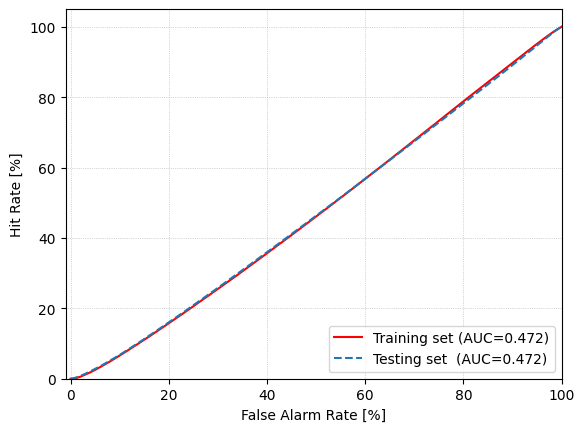

In [30]:
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train.flatten(), pred_y_train.flatten(), color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test.flatten(), pred_y_test.flatten(), linestyle='--')
plt.legend(loc='lower right');

### Reliability diagram

In [ ]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test.flatten(), pred_y_test.flatten())

plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label='Hello')

plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()